<a href="https://colab.research.google.com/github/MohammadHHasan2/ME4452/blob/main/Gradient%20Descent/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This handout is heavily based on the online web resource *Machine Learning for Mechanical Engineering* by Mark Fuge and uses their code and examples. All credit for the code is given to the original source. This document merely adapts the code as a jupyter notebook for ease of use. You may see the full course in the following link: https://ideal.umd.edu/ML4ME_Textbook/.**

# Introduction

Machine learning models require training to achieve the required performance. Interestingly, the process of training machine learning models is very similar to numerical optimization in which a cost function (or a reward function) is proposed and the training process is used to minimize the cost function (or maximize the reward function).

Some simple machine learning approaches like linear regression can be optimized using a single analytical equation. Recall that, for a linear regression model from before:

$\mathbf{w}=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$ ... (1)

Complex models are not as easy to train and may require complex iterative techniques to solve. One of the most commonly used techniques in machine learning is *gradient descent*. This set of course notes will explain the concept of gradient descent and its implimination. This concept will be essential for models like *Neural Networks*, which we will see later.


Let's start with some synthetic data of some linear data points with added noise.

Coefficient: 42.38


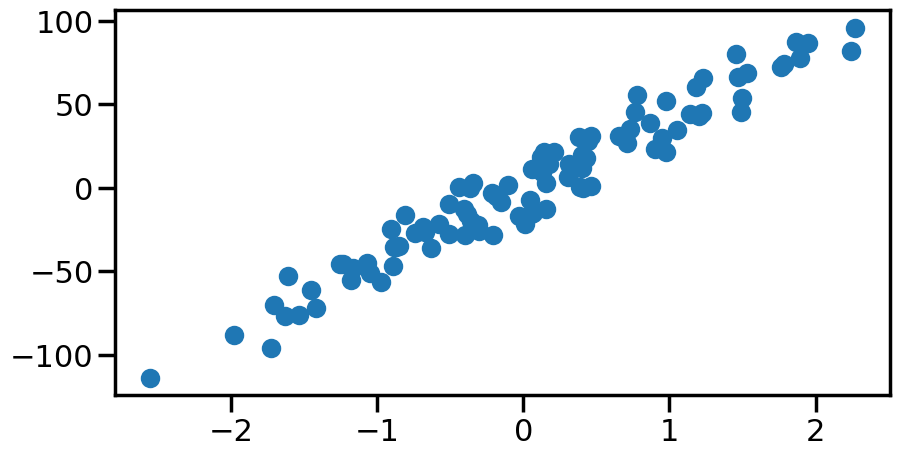

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
sns.set_context('poster')


n_samples = 100   # How many datapoints do we want?

X, y, coef = make_regression(n_samples=n_samples, # How many data?
                               n_features=1,    # How many dimensions?
                               n_informative=1, # How many dimensions matter?
                               noise=10,   # Add noise to the line
                               coef=True,  # Return the coefficients for us
                               random_state=0)  # Same random numbers every time

print("Coefficient: {:.5s}".format(str(coef)))
plt.figure(figsize=(10,5))
plt.scatter(X,y)
plt.show()

We can simply apply equation (1) to the data above to find the weights needed for the linear fit.

[[42.57166256]]


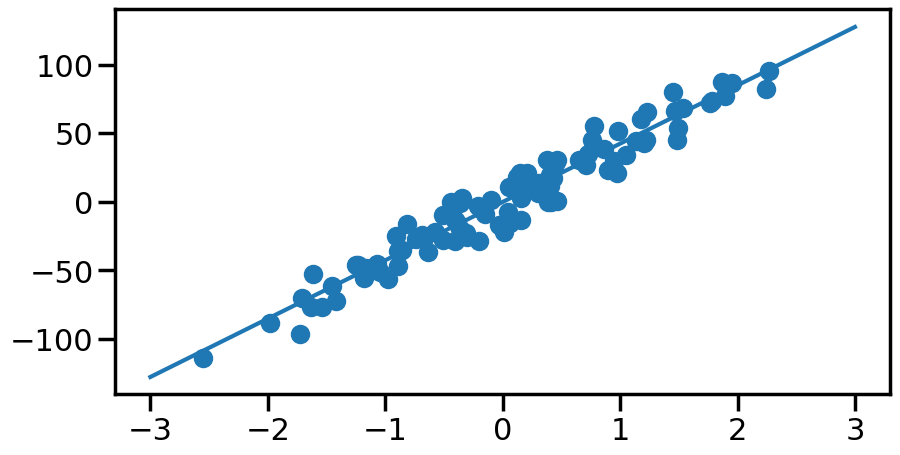

In [2]:
X = np.matrix(X)
y = np.matrix(y).T
wn = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
print(wn)

plt.figure(figsize=(10,5))
plt.scatter(np.asarray(X).ravel(),np.asarray(y).ravel())
plt.plot([-3,3],[-3*wn[0,0], 3*wn[0,0]])
plt.show()

Let's consider another approach for finding the correct weights for linear regression now. Let's look into Gradient Descent. More specifically, let's look at a particular type of approaches with that family called *Stocastic Gradient Descent* (SGD).

## Stocastic Gradient Descent (SGD)

SGD, as well as many optimization techniques is based on the idea of following the gradient (variable specific slope) of a function to reach a point of maximum or minimum. Before getting to the gradient of a function, let's start with the function itself:

Consider the following loss function:

$L = \frac{1}{N}\sum_{i=1}^N(y_i-f(\mathbf{w},\mathbf{x_i}))^2$

where $L$ is the loss function, in this case, it is a mean squared error function, a commonly used loss function. For a linear regression model, this equation converts to:

$L = \frac{1}{N}\sum_{i=1}^N(y_i-\mathbf{w}^T\mathbf{x}_i)^2$

Let's see the loss function and how it gives us information about the optimal $\mathbf{w}$

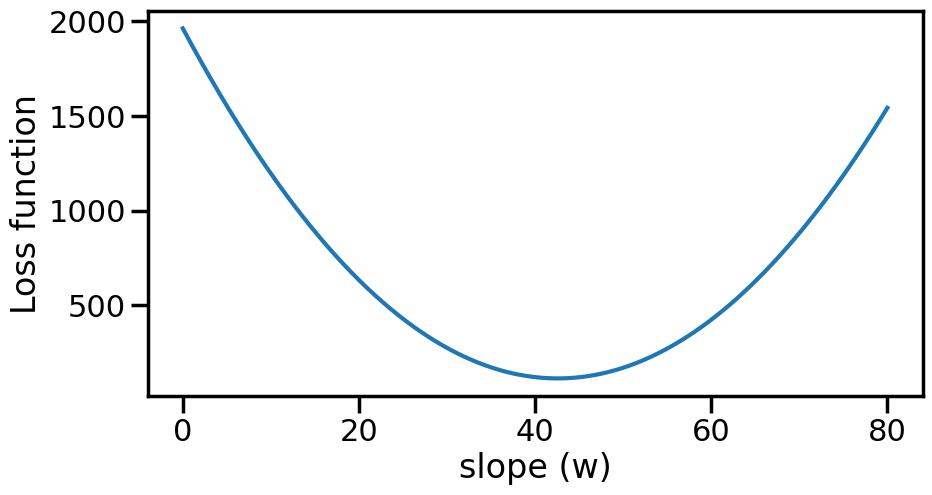

In [3]:
def loss(w):
    N = len(y)
    return np.sum(np.square(y-w*X))/N

wp = np.linspace(0,80,1000)
cost = [loss(w) for w in wp]
plt.figure(figsize=(10,5))
plt.plot(wp,cost)
plt.ylabel('Loss function')
plt.xlabel('slope (w)')
plt.show()

Note that the loss (error) is at a mimim at a value of $\mathbf{w}$ close to 40. Comparing that with the analytical results from before, the value should be around 42.38. The optimal value of $\mathbf{w}$ is thus one that is visably easy to find.

Since the slope of the parabolic curve shown here leads directly towards the curve minimum, we can iteratively update our weights using the slope (or gradient in systems with multiple variables):

$w_{t+1} ← w_t - \alpha \frac{\partial L}{\partial w}$

Where $t = 0,1,...,T$ is the iteration step and $\alpha$ is the learning rate, which will be discussed later.

The approach of gradient descent is not limited to linear regression models as you will see later. However, at this stage, let's see what the gradient looks like for our system:

$\frac{\partial L}{\partial w} = \frac{\partial}{\partial w} (\frac{1}{N} \sum_{i=1}^N (y_i - wx_i)^2)$


$\frac{\partial L}{\partial w} = -\frac{2}{N} \sum_{i=1}^N (y_i - wx_i)x_i$


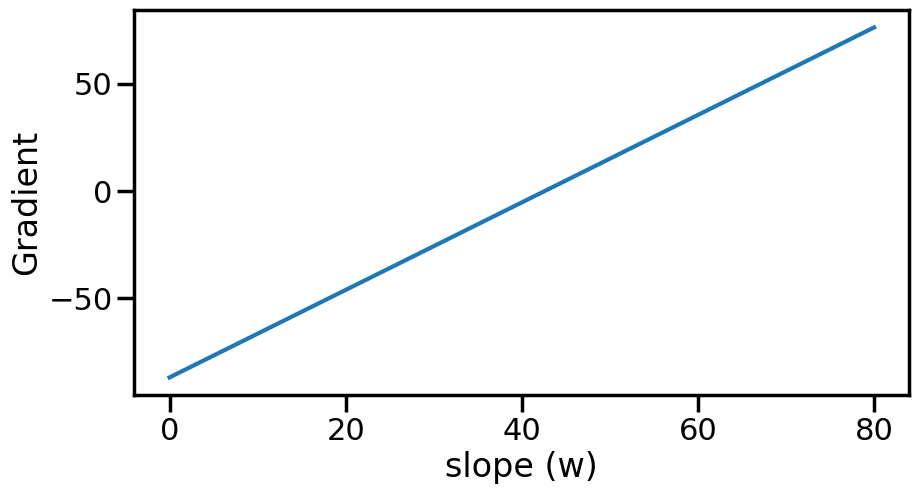

In [4]:
def dloss(w,X):
    N = len(y)
    return -2*np.sum(np.multiply(y-w*X,X))/N

grad = [dloss(w,X) for w in wp]
plt.figure(figsize=(10,5))
plt.plot(wp,grad)
plt.ylabel('Gradient')
plt.xlabel('slope (w)')
plt.show()

In [5]:
def grad_step(w, X, alpha):
    return w - alpha*dloss(w,X)

In [6]:
wg = 50  # Start at 50
wg = grad_step(wg, X, 0.1)  # Take a small step
print(wg)  # Now we are at...

48.4855051874447


In [8]:
######################
# Try changing the below
wg = 80 # Initial guess at slope; Try changing this
alpha = 0.1  # Try changing alpha (both big and small)
# What do you notice?
###########################


num_steps = 20 # Take 20 steps
weights = np.zeros(num_steps)
weights[0] = wg  # Set the initial weight
for i in range(1,num_steps):
    weights[i] = grad_step(weights[i-1], X, alpha)
print("Final weight from Gradient Descent is {:.2f}".format(weights[i]))
print("Compared to {:.2f} from the Normal Equations".format(wn[0,0]))

Final weight from Gradient Descent is 43.06
Compared to 42.57 from the Normal Equations


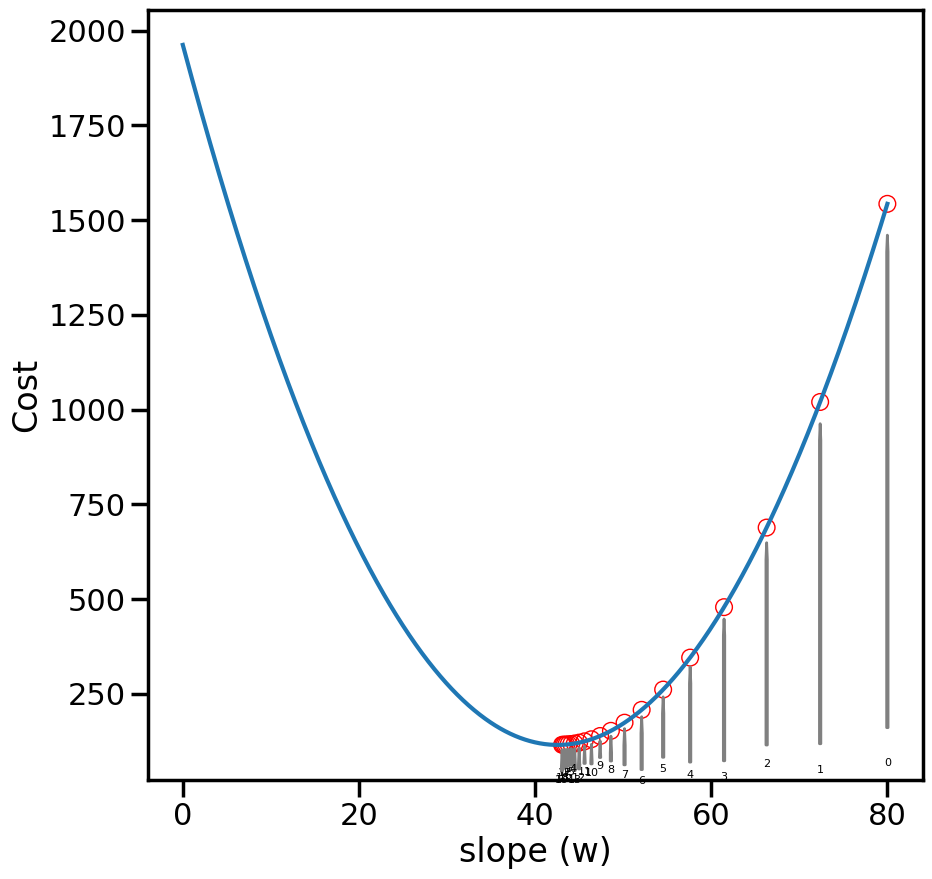

In [9]:
weight_cost = [loss(w) for w in weights]
plt.figure(figsize=(10,10))
plt.plot(wp,cost)
plt.scatter(weights,weight_cost,facecolors='none', edgecolors='r',linewidth=1)
ax = plt.gca()
for i,w in enumerate(weights):
    ax.annotate('{}'.format(i), xy=(w, weight_cost[i]-10),
                xytext=(w+1e-8, 10+50*np.random.rand()),
                ha='center',fontsize=8,
                arrowprops=dict(facecolor='white', edgecolor='grey',
                                shrink=0.05,
                            width=1, headwidth=1)
               )
plt.ylabel('Cost')
plt.xlabel('slope (w)')
plt.show()

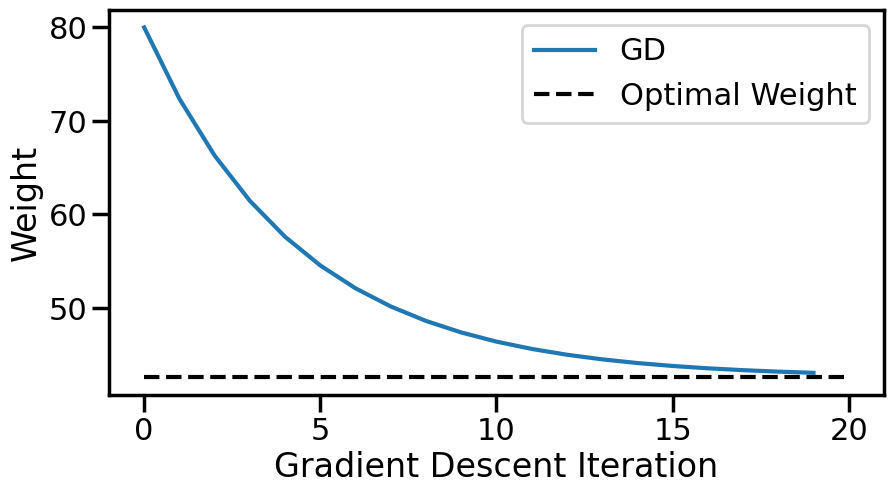

In [10]:
# Plot how the weights progress
plt.figure(figsize=(10,5))
plt.plot(range(len(weights)),weights, label='GD')
plt.hlines(wn, 0, len(weights),
           label = "Optimal Weight",
           color='k', linestyle="--")
plt.xlabel('Gradient Descent Iteration')
plt.ylabel('Weight')
plt.legend()
plt.show()
# Copying for comparison later
gd_weights = weights


## Stochastic Gradient Descent

A varient of Gradient Descent that is commonly used in machine learning is Stochastic Gradient Descent (SGD). Unlike the the previous version of gradient descent, this approach does not use all of the data $(X,Y)$, rather, it uses a small batch of data if that is feasible:

$w_{t+1} ← w_t - \alpha \frac{\partial L(w,x_i)}{\partial w}$



In [11]:
def sgd_dloss(w,y,x):
    return float(-2*(y-w*x)*x)

In [24]:
#################################
# Try Changing the below
wg = 80 # Initial guess at slope
alpha = 0.1  # Step Size
num_passes = 40  # Number of times we pass through the data
shuffle_after_pass = False  # Whether to shuffle the data
##########################
# What do you find?

N = len(y)
weights = np.zeros(N*num_passes+1)
k=0
weights[k] = wg  # Set the initial weight
print('Initial weight: ',weights[0])

index = list(range(N))
for n in range(num_passes):
    if shuffle_after_pass:
        np.random.shuffle(index)
    for i in index:
        k+=1
        xi = X[i,0]
        yi = y[i]
        weights[k] = weights[k-1] - alpha*sgd_dloss(weights[k-1],yi,xi)
print('Final Weight from SGD: {:.2f}'.format(weights[-1]))
print("Compared to {:.2f} (Normal Equations)".format(wn[0,0]))

Initial weight:  80.0
Final Weight from SGD: 38.94
Compared to 42.57 (Normal Equations)


/tmp/ipykernel_35848/3561310644.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(-2*(y-w*x)*x)


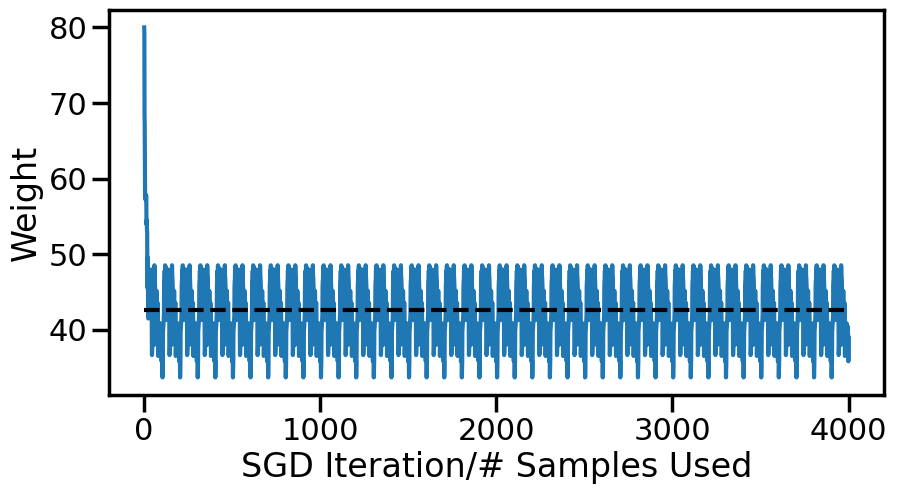

In [25]:
plt.figure(figsize=(10,5))
plt.plot(range(len(weights)),weights)
plt.hlines(wn[0,0], 0, len(weights),
           label = "Optimal Weight",
           color='k', linestyle="--")
plt.xlabel('SGD Iteration/# Samples Used')
plt.ylabel('Weight')
plt.show()

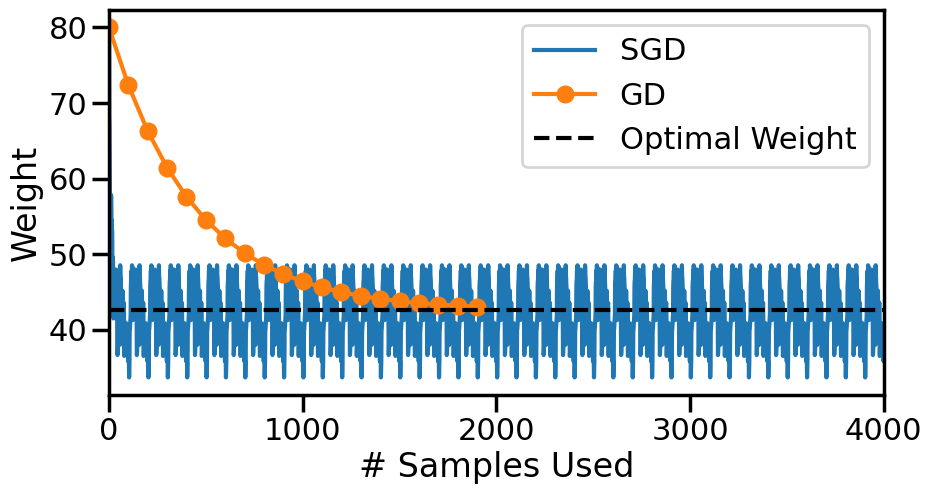

In [26]:
plt.figure(figsize=(10,5))
plt.plot(range(len(weights)), weights,
         label = 'SGD')
plt.plot(np.array(range(len(gd_weights)))*len(index),
         gd_weights,
         marker='o',
         label = 'GD')
plt.hlines(wn, 0, len(weights),
           label = "Optimal Weight",
           color='k', linestyle="--")
plt.xlabel('# Samples Used')
plt.ylabel('Weight')
#plt.ylim([30,55])
plt.xlim([0,len(weights)])
plt.legend()
plt.show()

### Observations

Notice that SGD tries to approximate the gradient $\frac{\partial L}{\partial w}$ using a single datapoint at a time. This results in a noisy estimate of the gradient.

Notice that using small learning rate $\alpha$, SGD tends to get close to GD. This slows down SGD, however. Unfortuantely, increasing $\alpha$ increases noise, which is not ideal.

A good idea is to schedule the learning rate such that one starts with a high learning rate for quick convergence. The learning rate is reduced over time to enhance convergence.

Initial weight:  80.0
Final Weight from SGD: 42.67
Compared to 42.57 (Normal Equations)


/tmp/ipykernel_35848/3561310644.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(-2*(y-w*x)*x)


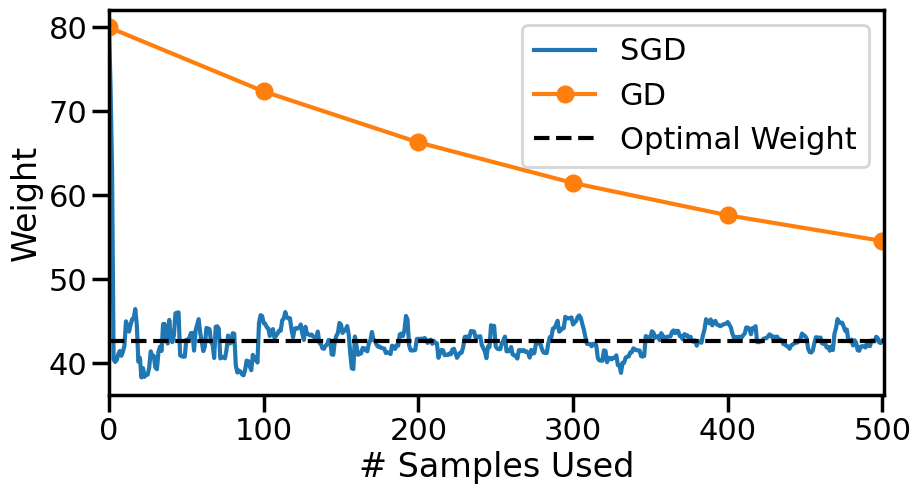

In [28]:
#################################
# Try Changing the below
wg = 80 # Initial guess at slope
alpha_i = 0.5  # Initial Step Size
#alpha = lambda n: alpha_i
#alpha = lambda n: alpha_i/n
alpha = lambda n: alpha_i/np.sqrt(n)
num_passes = 5  # Number of times we pass through the data
shuffle_after_pass = True  # Whether to shuffle the data
##########################
# What do you find?

N = len(y)
weights = np.zeros(N*num_passes+1)
k=0
weights[k] = wg  # Set the initial weight
print('Initial weight: ',weights[0])

index = list(range(N))
for n in range(num_passes):
    if shuffle_after_pass:
        np.random.shuffle(index)
    for i in index:
        k+=1
        xi = X[i,0]
        yi = y[i]
        weights[k] = weights[k-1] - alpha(k)*sgd_dloss(weights[k-1],yi,xi)
print('Final Weight from SGD: {:.2f}'.format(weights[-1]))
print("Compared to {:.2f} (Normal Equations)".format(wn[0,0]))

plt.figure(figsize=(10,5))
# Plot SGD Weights
plt.plot(range(len(weights)), weights,
         marker=None,
         label = 'SGD')
# Plot Grad. Descent Weights
plt.plot(np.array(range(len(gd_weights)))*len(index),
         gd_weights,
         marker='o',
         label = 'GD')
# Plot True Answer
plt.hlines(wn, 0, len(weights),
           label = "Optimal Weight",
           color='k', linestyle="--")
plt.xlabel('# Samples Used')
plt.ylabel('Weight')
#plt.ylim([30,55])
plt.xlim([0,len(weights)])
plt.legend()
plt.show()

# Existing Packages

SGD is a commonly used technique for learning. As such, some packages already exist to implement SGD with minimal programming needed. Below is an example of such implmentation.

In *ScikitLearn*, learning rate, called $\eta$ there, is upadated according to the rule:

$\eta_t = \frac{\eta_0}{t^{\text{power}}}$

In [29]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(loss = 'squared_error',
                   eta0 = 0.01,  # Initial Learning rate/step size
                   power_t = 0.25, # how quickly sould eta decay?
                   max_iter = 100,  # Max # of passes to do over the data?
                   tol = 1e-3,     # Tolerance for change in loss
                   fit_intercept=False # Not worrying about b term in w*x+b
                  )
# Here eta = eta0/(t^power_t) where t is the iteration
X = np.asarray(X)
y = np.array(y).reshape(len(y),) # Reshape y so that scikit doesn't complain
sgd.fit(X,y)
print('Final Weight from SKLearn SGD: {:.2f}'.format(sgd.coef_[0]))
print("Compared to {:.2f} (Normal Equations)".format(wn[0,0]))

Final Weight from SKLearn SGD: 42.54
Compared to 42.57 (Normal Equations)


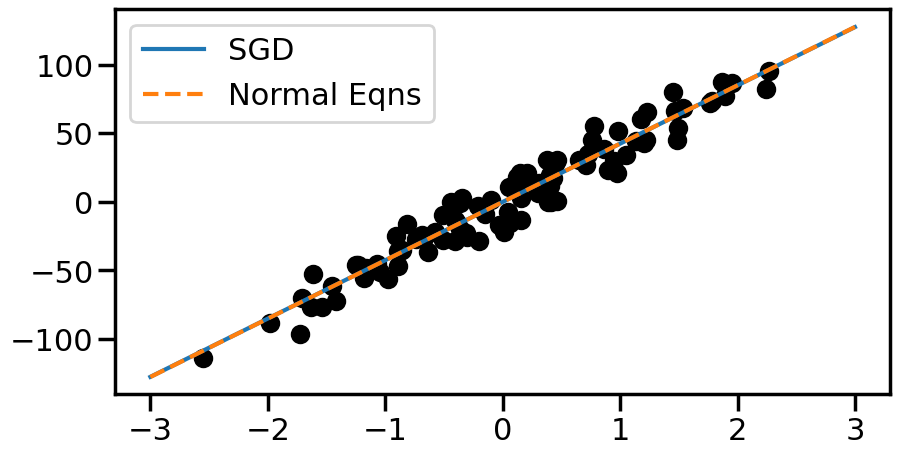

In [31]:
plt.figure(figsize=(10,5))
plt.scatter(np.asarray(X).ravel(),
            np.asarray(y).ravel(),
            color='k'
           )
#plt.scatter(X,y)
Xp = [[-3],[3]]
plt.plot(Xp,sgd.predict(Xp),label='SGD')
plt.plot([-3,3],[-3*wn[0,0], 3*wn[0,0]],
         label='Normal Eqns',
         linestyle='--' )
plt.legend()
plt.show()

# Additional concepts related to SGD

momentum

batching

normalizing gradient updates